#1)Problem Statement:
The goal of this project is to predict the number of calories burned during exercise using machine learning.

Two datasets are used in this project. The first dataset contains exercise information such as User_ID, Gender, Age, Height, Weight, Duration, Heart_Rate, and Body_Temp. The second dataset contains the calories burned by each user.

Both datasets are merged using the common column User_ID. After merging the datasets, data preprocessing steps are performed, including handling missing values, removing errors, and encoding categorical variables.

The target variable in this project is Calories, and the remaining columns are used as input features. A Linear Regression model is used to train the dataset and predict calories burned during exercise.

#2)Import Libraries:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#3)Load Dataset:

In [3]:
df1=pd.read_csv("/content/exercise.csv")

In [4]:
df1

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8
...,...,...,...,...,...,...,...,...
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3


In [5]:
df2=pd.read_csv("/content/calories.csv")

In [6]:
df2

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0
...,...,...
14995,15644082,45.0
14996,17212577,23.0
14997,17271188,75.0
14998,18643037,11.0


In [7]:
df=pd.merge(df1,df2,on="User_ID")

In [8]:
df

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0


#4)Feature Selection:


In [9]:
df.drop("User_ID",axis=1,inplace=True)

In [10]:
df

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...
14995,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,male,78,193.0,97.0,2.0,84.0,38.3,11.0


#5)Handle Missing Values (NaNs):

In [11]:
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


In [12]:
df.isna().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


#6)Remove Errors / Data Cleaning:

In [13]:
df

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...
14995,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,male,78,193.0,97.0,2.0,84.0,38.3,11.0


In [14]:
df["Gender"].unique()

array(['male', 'female'], dtype=object)

In [15]:
df["Gender"].value_counts()

,count
Gender,
female,7553
male,7447


<Axes: >

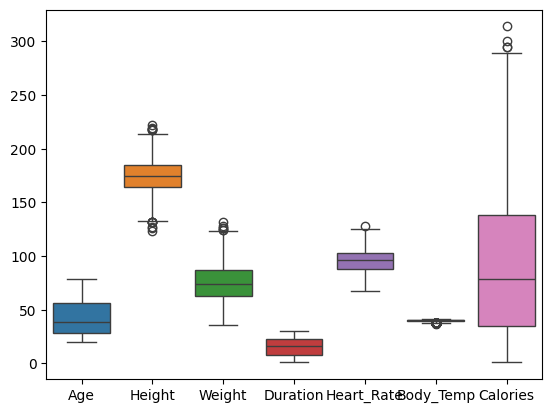

In [16]:
sns.boxplot(df)

In [17]:
cols=["Height","Weight","Heart_Rate","Body_Temp","Calories"]

In [18]:
df[cols]

,Height,Weight,Heart_Rate,Body_Temp,Calories
0,190.0,94.0,105.0,40.8,231.0
1,166.0,60.0,94.0,40.3,66.0
2,179.0,79.0,88.0,38.7,26.0
3,179.0,71.0,100.0,40.5,71.0
4,154.0,58.0,81.0,39.8,35.0
...,...,...,...,...,...
14995,193.0,86.0,92.0,40.4,45.0
14996,165.0,65.0,85.0,39.2,23.0
14997,159.0,58.0,90.0,40.1,75.0
14998,193.0,97.0,84.0,38.3,11.0


In [19]:
for c in cols:
  q1=df[c].quantile(0.25)
  q3=df[c].quantile(0.75)
  iqr=q3-q1
  lower=q1-(1.5*iqr)
  upper=q3+(1.5*iqr)
  df[c]=df[c].map(lambda x:lower if x<lower else upper if x>upper else x)

<Axes: >

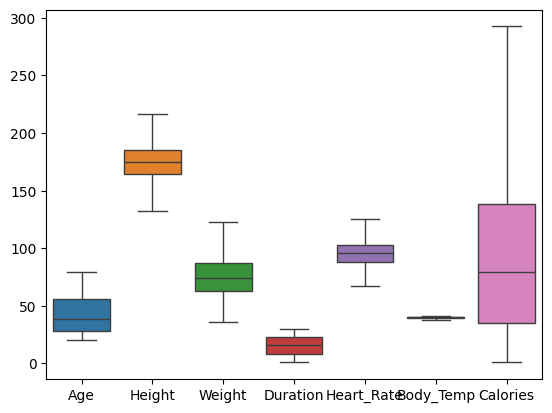

In [20]:
sns.boxplot(df)

#6)Encoding Categorical Data:

In [21]:
from sklearn.preprocessing import LabelEncoder

In [22]:
oh=LabelEncoder()

In [23]:
df["Gender"]=oh.fit_transform(df["Gender"])  #oh.fit_transform()

In [24]:
df["Gender"]

,Gender
0,1
1,0
2,1
3,0
4,0
...,...
14995,0
14996,0
14997,0
14998,1


In [26]:
df

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,1,68,190.0,94.0,29.0,105.0,40.8,231.0
1,0,20,166.0,60.0,14.0,94.0,40.3,66.0
2,1,69,179.0,79.0,5.0,88.0,38.7,26.0
3,0,34,179.0,71.0,13.0,100.0,40.5,71.0
4,0,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...
14995,0,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,0,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,0,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,1,78,193.0,97.0,2.0,84.0,38.3,11.0


#7)Separate Features and Target:



In [27]:
X=df.drop("Calories",axis=1)

In [28]:
X

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,1,68,190.0,94.0,29.0,105.0,40.8
1,0,20,166.0,60.0,14.0,94.0,40.3
2,1,69,179.0,79.0,5.0,88.0,38.7
3,0,34,179.0,71.0,13.0,100.0,40.5
4,0,27,154.0,58.0,10.0,81.0,39.8
...,...,...,...,...,...,...,...
14995,0,20,193.0,86.0,11.0,92.0,40.4
14996,0,27,165.0,65.0,6.0,85.0,39.2
14997,0,43,159.0,58.0,16.0,90.0,40.1
14998,1,78,193.0,97.0,2.0,84.0,38.3


In [29]:
y=df["Calories"]

In [30]:
y

,Calories
0,231.0
1,66.0
2,26.0
3,71.0
4,35.0
...,...
14995,45.0
14996,23.0
14997,75.0
14998,11.0


#8)Train-Test Split:


In [31]:
from sklearn.model_selection import train_test_split

In [32]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=22)

In [33]:
x_train.shape

(12000, 7)

In [34]:
x_test.shape

(3000, 7)

In [35]:
y_train.shape

(12000,)

In [36]:
y_test.shape

(3000,)

#8)Build and Train Model:

In [37]:
from sklearn.linear_model import LinearRegression

In [38]:
lr_model=LinearRegression()

In [39]:
lr_model.fit(x_train,y_train)

LinearRegression()

#9)Model Evaluation

In [40]:
lr_model.score(x_test,y_test)

0.9671264055920377

#10)Conclusion:
In this project, two datasets related to exercise and calories were combined using the common column User_ID. Data preprocessing steps such as handling missing values, removing errors, and encoding categorical variables were performed to prepare the data.

A Linear Regression algorithm was applied to train the model and predict calories burned based on exercise features. The model achieved an accuracy score of 96%, which shows that the model performs well on the dataset.

This project shows how machine learning can be used to analyze exercise data and estimate calories burned using different physical and activity-related features.